### Univariate data analyses - NHANES case study
Here we will demonstrate how to use Python and Pandas to perform some basic analyses with univariate data, using the 2015-2016 wave of the NHANES cross-sectional study to illustrate the techniques.

In [396]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

In [397]:
project_root = Path.cwd().parents[0]
fname = project_root / "datasets" / "nhanes_2015_2016.csv"

df = pd.read_csv(fname)
# df

- value_counts can be used to determine the number of times each distinct value of a variable occured in a dataset.  
- this is the "frequency distribution" of the variable.  
- below we show DMDEDUC2 frequency distribtion, DMDEDUC2 shows a person's level of educational attainment.  
- The numbers 1, 2, 3, 4, 5, 9 seen below are integer codes for the 6 possible non-missing values of the DMDEDUC2 variable.  
- value_counts excludes missing values

In [398]:
df.DMDEDUC2.value_counts()

DMDEDUC2
4.0    1621
5.0    1366
3.0    1186
1.0     655
2.0     643
9.0       3
Name: count, dtype: int64

In [399]:
print("###### display count of all values using the len function: ")
print((f"total: {len(df)}", f"existing values: {df.DMDEDUC2.value_counts().sum()}"))

print("\n###### display all values using value_counts and dropna flag as false: ")
print(f"all values: {df.DMDEDUC2.value_counts(dropna=False).sum()}")

print("\n###### display missing values using isna function on the df object: ")
print(f"Missing values DMDEDUC2: {df.DMDEDUC2.isna().sum()}")

print("\n###### display shape:")
print(f"df shape: {df.shape}")

print("\n###### Another way using isna and notna methods on the df object: ")
print(f"NAN values: {df["DMDEDUC2"].isna().sum()}")
print(f"complementary, non NAN: {df["DMDEDUC2"].notna().sum()}")

print("\n###### Another way using isnull pandas function: ")
print(f"existing values: {pd.isnull(df.DMDEDUC2).sum()}")


###### display count of all values using the len function: 
('total: 5735', 'existing values: 5474')

###### display all values using value_counts and dropna flag as false: 
all values: 5735

###### display missing values using isna function on the df object: 
Missing values DMDEDUC2: 261

###### display shape:
df shape: (5735, 28)

###### Another way using isna and notna methods on the df object: 
NAN values: 261
complementary, non NAN: 5474

###### Another way using isnull pandas function: 
existing values: 261


In [400]:
# replacing the integer codes with a text label that reflects the code's meaning
print("###### display frequency table of the DMDEDUC2 variable: ")
display(df.DMDEDUC2.value_counts())

# here we cerate a new variable 'DMDEDUC2x' that is recoded with text labels
df["DMDEDUC2x"] = df.DMDEDUC2.replace({1:"<9", 2:"9-11", 3:"HS/GED", 4:"Some College/AA", 5:"College", 7:"Refused", 9:"Don't know"})

#generate its frequency distribution
df.DMDEDUC2x.value_counts()

###### display frequency table of the DMDEDUC2 variable: 


DMDEDUC2
4.0    1621
5.0    1366
3.0    1186
1.0     655
2.0     643
9.0       3
Name: count, dtype: int64

DMDEDUC2x
Some College/AA    1621
College            1366
HS/GED             1186
<9                  655
9-11                643
Don't know            3
Name: count, dtype: int64

In [401]:
# same way replace the values 1 and 2 with male and female for the RIAGENDR variable
display(df.RIAGENDR.value_counts())
df["RIAGENDRx"] = df.RIAGENDR.replace({1:"Male", 2:"Female"})
df.RIAGENDRx.value_counts()

RIAGENDR
2    2976
1    2759
Name: count, dtype: int64

RIAGENDRx
Female    2976
Male      2759
Name: count, dtype: int64

In [402]:
# For many purposes it is more relevant to consider the proportion of the sample with each of the possible category values, 
# rather than the number of people in each category. We can do this as follows:
df.DMDEDUC2x.value_counts() / df.DMDEDUC2x.value_counts().sum()

DMDEDUC2x
Some College/AA    0.296127
College            0.249543
HS/GED             0.216661
<9                 0.119657
9-11               0.117464
Don't know         0.000548
Name: count, dtype: float64

In [403]:
# using the describe df method, we can get statistical summaries
# dropna to drop missing values, yet I think the describe method does it perhaps
df.BMXWT.dropna().describe()

count    5666.000000
mean       81.342676
std        21.764409
min        32.400000
25%        65.900000
50%        78.200000
75%        92.700000
max       198.900000
Name: BMXWT, dtype: float64

In [404]:
# we can also calculate statistical data individually
bmxwt = df.BMXWT.dropna()

print("mean:") # numpy method
print(f"pandas mean: {bmxwt.mean()}") # pandas method
print(f"numpy mean:  {np.mean(bmxwt)}") # numpy method

print("\nmedian:") # numpy method
print(f"pandas median: {bmxwt.median()}") # pandas method
print(f"numpy median: {np.percentile(bmxwt, 50)}") # numpy method

print("\n75 percentile:") # numpy method
print(f"pandas 75 quantile : {bmxwt.quantile(0.75)}") # pandas method
print(f"numpy 75 percentile: {np.percentile(bmxwt, 75)}") # numpy method



mean:
pandas mean: 81.34267560889516
numpy mean:  81.34267560889516

median:
pandas median: 78.2
numpy median: 78.2

75 percentile:
pandas 75 quantile : 92.7
numpy 75 percentile: 92.7


In [405]:
# for the systolic blood pressure variable "BPXSY1"
# pre-hypertension is when a person is having systolic bp between 120 and 139
# or diastolic pressure between  80 and 89
print(f"count of people with pre-hypertension based on systolic pressure: {((df.BPXSY1 >= 120) & (df.BPXSY1 <= 139)).sum()}")
print(f"count of all dataset: {len(df)}")
print(f"mean of people with pre-hypertension based on systolic pressure: {np.mean((df.BPXSY1 >= 120) & (df.BPXSY1 <= 139))}")

count of people with pre-hypertension based on systolic pressure: 2104
count of all dataset: 5735
mean of people with pre-hypertension based on systolic pressure: 0.366870095902354


In [406]:
# proportion of people with pre-hypertension based on diastolic pressure
print(f"count of people with pre-hypertension based on diastolic pressure: {((df.BPXDI1 >= 80) & (df.BPXDI1 <= 89)).sum()}")
print(f"mean of people with pre-hypertension based on diastolic pressure: {np.mean((df.BPXDI1 >= 80) & (df.BPXDI1 <= 89))}")

count of people with pre-hypertension based on diastolic pressure: 843
mean of people with pre-hypertension based on diastolic pressure: 0.14699215344376634


In [407]:
# since there are some people who may can be hypertensive under both criteria
# the proportion can be less the sum of both
# | means OR, counts each person once
sys_hypertensive_bool = (df.BPXSY1 >= 120) & (df.BPXSY1 <= 139)
dia_hypertensive_bool = (df.BPXDI1 >= 80) & (df.BPXDI1 <= 89)
print(f"count of people with pre-hypertension based on both systolic and diastolic pressure: {(sys_hypertensive_bool | dia_hypertensive_bool).sum()}")
print(f"hypertensive people total proportion: {np.mean(sys_hypertensive_mean | dia_hypertensive_mean)}")

count of people with pre-hypertension based on both systolic and diastolic pressure: 2476
hypertensive people total proportion: 0.43173496076721884


In [408]:
# in this dataset, both systolic and diastolic blood pressures are measured twice
# patients blood pressure can be slightly elevated when dealing with healthcare providers, "the white coat effect"
# calculate to what extent the white coat anxiety is present by looking at the mean in the difference between bp measurements
print(f"mean in systolic pressure difference: {np.mean(df.BPXSY1 - df.BPXSY2)}")
print(f"mean in diastolic pressure difference: {np.mean(df.BPXDI1 - df.BPXDI2)}")

mean in systolic pressure difference: 0.6749860309182343
mean in diastolic pressure difference: 0.3490407897187558


These mean differences are positive -- the first systolic blood pressure measurement is around 0.67 mm Hg greater than the second systolic blood pressure measurement, and the first diastolic blood pressure measurement is around 0.35 mm Hg greater than the second diastolic blood pressure measurement. This is consistent with the presence of "white coat hypertension".

## Graphical Summaries
Quantitative variables can be effectively summarized graphically.

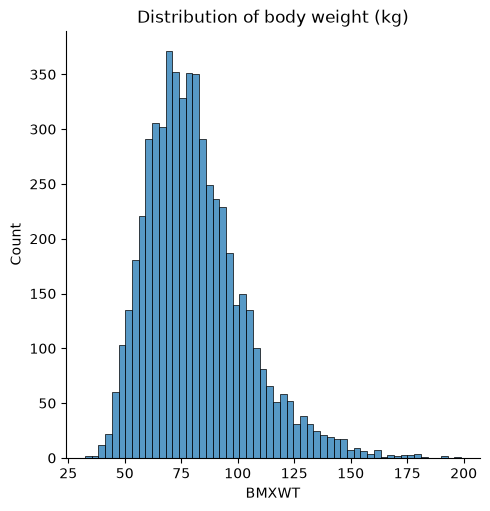

In [409]:
# distribution of body weight in kg
# looks like it is right-skewed
facetgrid = sns.displot(data=df.BMXWT.dropna(), kind='hist')
facetgrid.set(title="Distribution of body weight (kg)")

Text(0.5, 1.0, 'Histogram of Systolic blood pressure')

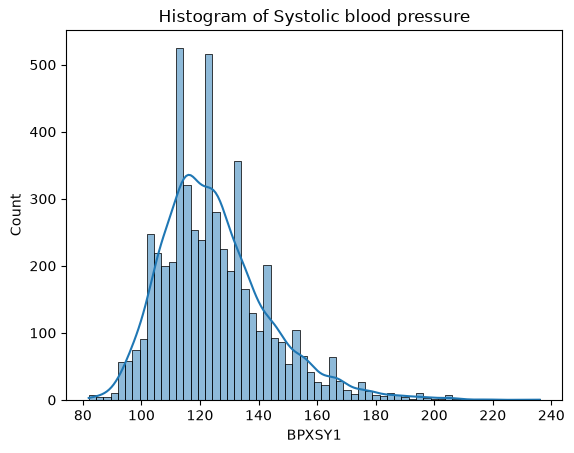

In [410]:
# display histogram of systolic blood pressure
ax = sns.histplot(df.BPXSY1.dropna(), kde=True)
ax.set_title("Histogram of Systolic blood pressure")

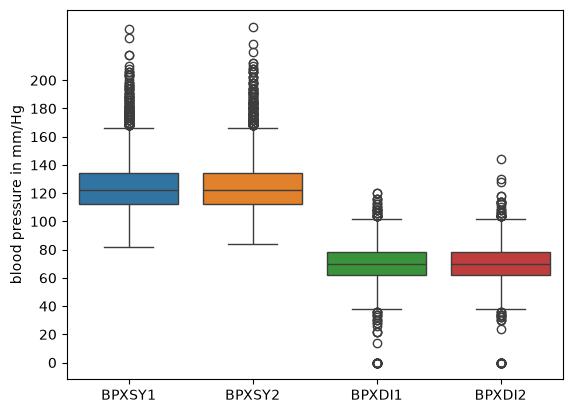

In [411]:
# to compare several distributions, we can compare side by side box plots
bp = sns.boxplot(data=df.loc[:, ["BPXSY1", "BPXSY2", "BPXDI1", "BPXDI2"]])
bp.set_ylabel("blood pressure in mm/Hg")

# bp.yaxis.set_major_locator(ticker.MaxNLocator(15))
# to prevent output of the line, either assign to a var like _ or add semicolon at the end
_ = bp.yaxis.set_ticks(range(0, 201, 20))

### Stratification:
divide the dataset into smaller, more uniform subsets and analyze each "strata" on its own.  
We can then formally or informally compare the findings in the different strata.  
When working with human subjects, it is very common to stratify on demographic factors such as age, sex, and race.  

#### example with blood pressure
To illustrate this technique, consider blood pressure, which is a value that tends to increase with age.  
To see this trend in the NHANES data, we can partition the data into age strata, and construct side-by-side boxplots of the systolic blood pressure (SBP) distribution within each stratum.  
Since age is a quantitative variable, we need to create a series of "bins" of similar SBP values in order to stratify the data. Each box in the figure below is a summary of univariate data within a specific population stratum (here defined by age).

/tmp/ipykernel_119555/558010724.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(data=df, x="agegrp", y="BPXSY1", palette="Set2")


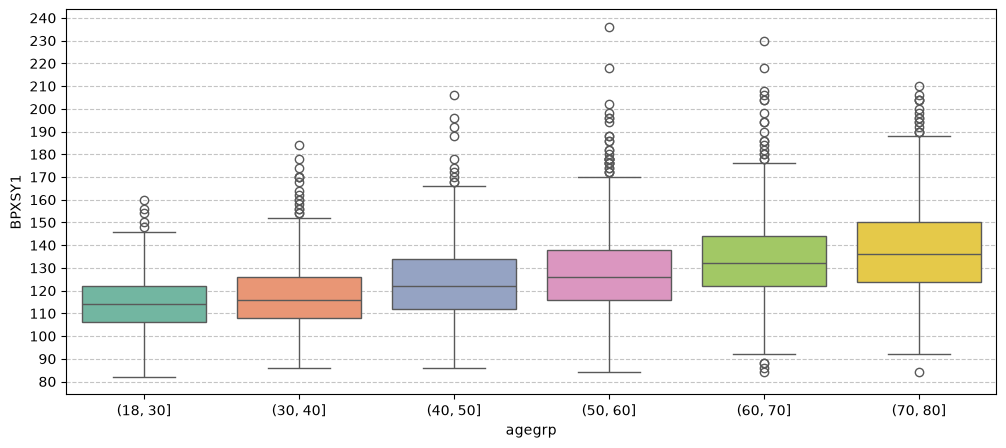

In [412]:
# Create age strata based on cut points
df["agegrp"] = pd.cut(df.RIDAGEYR, [18, 30, 40, 50, 60, 70, 80])

# increase width figure size than default
plt.figure(figsize=(12, 5))

# make boxplot of BPXSY1 stratified by age group
bp = sns.boxplot(data=df, x="agegrp", y="BPXSY1", palette="Set2")

_ = bp.yaxis.set_ticks(range(80, 241, 10))
plt.grid(axis="y", linestyle="--", alpha=0.75)

aking this a step further, it is also the case that blood pressure tends to differ between women and men.  
While we could simply make two side-by-side boxplots to illustrate this contrast, it would be a bit odd to ignore age after already having established that it is strongly associated with blood pressure. Therefore, we will doubly stratify the data by gender and age.

We see from the figure below that within each gender, older people tend to have higher blood pressure than younger people. However within an age band, the relationship between gender and systolic blood pressure is somewhat complex -- in younger people, men have substantially higher blood pressures than women of the same age. However for people older than 50, this relationship becomes much weaker, and among people older than 70 it appears to reverse. It is also notable that the variation of these distributions, reflected in the height of each box in the boxplot, increases with age.

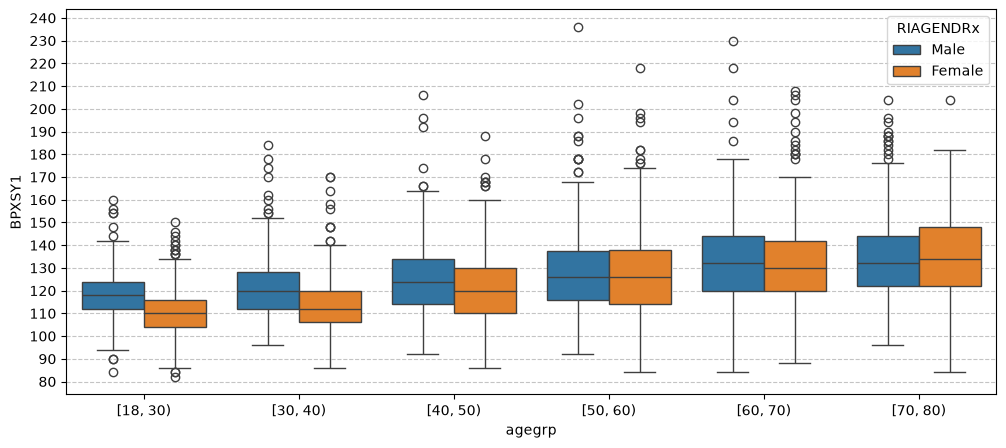

In [413]:
df.RIAGENDRx.unique()
# if we want only one gender we can use df.loc like this
# bp = sns.boxplot(data=df.loc[df.RIAGENDRx == "Male"], x="agegrp", y="BPXSY1", palette="Set2")

# Create age strata based on cut points
df["agegrp"] = pd.cut(df.RIDAGEYR, [18, 30, 40, 50, 60, 70, 80], right=False)

# increase width figure size than default
plt.figure(figsize=(12, 5))

# make boxplot of BPXSY1 stratified by age group
bp = sns.boxplot(data=df, x="agegrp", y="BPXSY1", hue="RIAGENDRx")

_ = bp.yaxis.set_ticks(range(80, 241, 10))
plt.grid(axis="y", linestyle="--", alpha=0.75)

When stratifying on two factors (here age and gender), we can group the boxes first by age, and within age bands by gender, as above, or we can do the opposite -- group first by gender, and then within gender group by age bands. Each approach highlights a different aspect of the data.

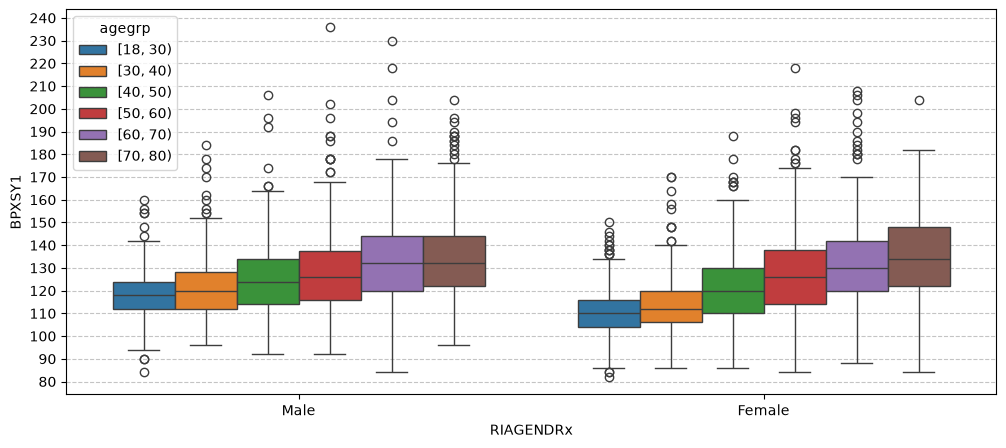

In [414]:
# Create age strata based on cut points
df["agegrp"] = pd.cut(df.RIDAGEYR, [18, 30, 40, 50, 60, 70, 80], right=False)

# increase width figure size than default
plt.figure(figsize=(12, 5))

# make boxplot of BPXSY1 stratified by age group
bp = sns.boxplot(data=df, x="RIAGENDRx", y="BPXSY1", hue="agegrp")

_ = bp.yaxis.set_ticks(range(80, 241, 10))
plt.grid(axis="y", linestyle="--", alpha=0.75)

Stratification can also be useful when working with categorical variables. Below we look at the frequency distribution of educational attainment ("DMDEDUC2") within 10-year age bands. While "some college" is the most common response in all age bands, up to around age 60 the second most common response is "college" (i.e. the person graduated from college with a four-year degree). However for people over 50, there are as many or more people with only high school or general equivalency diplomas (HS/GED) than there are college graduates.

Note on causality and confounding: An important role of statistics is to aid researchers in identifying causes underlying observed differences. Here we have seen differences in both blood pressure and educational attainment based on age. It is plausible that aging directly causes blood pressure to increase. But in the case of educational attainment, this is actually a "birth cohort effect". NHANES is a cross sectional survey (all data for one wave were collected at a single point in time). People who were, say, 65 in 2015 (when these data were collected), were college-aged around 1970, while people who were in their 20's in 2015 were college-aged in around 2010 or later. Over the last few decades, it has become much more common for people to at least begin a college degree than it was in the past. Therefore, younger people as a group have higher educational attainment than older people as a group. As these young people grow older, the cross sectional relationship between age and educational attainment will change.

In [415]:
# groupby splits the data frame into multiple dataframe containing (group agegrp, group dataframe)
# with each group dataframe containing the observations of that specific time
groups = {}

for name, group in df.groupby("agegrp"):
    #print(name.left, name.right)
    groups[f"{name.left}-{name.right-1}"] = group

print(groups.keys())

print(groups["18-29"].RIDAGEYR.unique())
print(groups["30-39"].RIDAGEYR.unique())
print(groups["40-49"].RIDAGEYR.unique())

dict_keys(['18-29', '30-39', '40-49', '50-59', '60-69', '70-79'])
[22 18 19 24 27 29 20 23 21 26 28 25]
[32 30 37 39 31 35 38 33 36 34]
[42 46 45 49 44 41 40 48 47 43]


In [416]:
# For each age group, count how many observations fall into each education category.
count = df.groupby("agegrp")["DMDEDUC2x"].value_counts()
percentage = df.groupby("agegrp")["DMDEDUC2x"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%"

edu_by_agegrp = pd.DataFrame({
    "Count": count,
    "Perncentage": percentage
})
display(edu_by_agegrp)

Count Perncentage
agegrp   DMDEDUC2x                         
[18, 30) Some College/AA    339       36.4%
         College            239       25.7%
         HS/GED             222       23.8%
         9-11                87        9.3%
         <9                  44        4.7%
[30, 40) Some College/AA    280       30.0%
         College            273       29.3%
         HS/GED             184       19.7%
         9-11               110       11.8%
         <9                  86        9.2%
[40, 50) College            273       29.9%
         Some College/AA    261       28.6%
         HS/GED             172       18.8%
         9-11               109       11.9%
         <9                  98       10.7%
[50, 60) Some College/AA    256       28.8%
         College            210       23.6%
         HS/GED             205       23.1%
         9-11               119       13.4%
         <9                  98       11.0%
[60, 70) Some College/AA    248       27.0%
         HS/GED             205       22.4%
         College            192       20.9%
         <9                 152       16.6%
         9-11               120       13.1%
[70, 80) Some College/AA    143       26.0%
         College            121       22.0%
         HS/GED             114       20.8%
         <9                 113       20.6%
         9-11                57       10.4%
         Don't know           1        0.2%

In [417]:
# Eliminate rare/missing values
dx = df.loc[~df.DMDEDUC2x.isin(["Don't know", "Missing"]), :]
count = dx.groupby(["agegrp","RIAGENDRx"])["DMDEDUC2x"].value_counts()
percentage = dx.groupby(["agegrp", "RIAGENDRx"])["DMDEDUC2x"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%"

edu_by_agegrp_gender = pd.DataFrame({
    "Count": count,
    "Perncentage": percentage
})
display(edu_by_agegrp_gender)

Count Perncentage
agegrp   RIAGENDRx DMDEDUC2x                         
[18, 30) Female    Some College/AA    190       38.4%
                   College            131       26.5%
                   HS/GED             113       22.8%
                   9-11                37        7.5%
                   <9                  24        4.8%
         Male      Some College/AA    149       34.2%
                   HS/GED             109       25.0%
                   College            108       24.8%
                   9-11                50       11.5%
                   <9                  20        4.6%
[30, 40) Female    Some College/AA    161       33.5%
                   College            157       32.6%
                   HS/GED              78       16.2%
                   9-11                43        8.9%
                   <9                  42        8.7%
         Male      Some College/AA    119       26.3%
                   College            116       25.7%
                   HS/GED             106       23.5%
                   9-11                67       14.8%
                   <9                  44        9.7%
[40, 50) Female    Some College/AA    157       30.7%
                   College            157       30.7%
                   HS/GED              86       16.8%
                   <9                  56       11.0%
                   9-11                55       10.8%
         Male      College            116       28.9%
                   Some College/AA    104       25.9%
                   HS/GED              86       21.4%
                   9-11                54       13.4%
                   <9                  42       10.4%
[50, 60) Female    Some College/AA    139       30.8%
                   College            111       24.6%
                   HS/GED             103       22.8%
                   9-11                53       11.8%
                   <9                  45       10.0%
         Male      Some College/AA    117       26.8%
                   HS/GED             102       23.3%
                   College             99       22.7%
                   9-11                66       15.1%
                   <9                  53       12.1%
[60, 70) Female    Some College/AA    139       29.7%
                   HS/GED              97       20.7%
                   College             92       19.7%
                   <9                  85       18.2%
                   9-11                55       11.8%
         Male      Some College/AA    109       24.3%
                   HS/GED             108       24.1%
                   College            100       22.3%
                   <9                  67       14.9%
                   9-11                65       14.5%
[70, 80) Female    Some College/AA     73       27.8%
                   HS/GED              58       22.1%
                   <9                  58       22.1%
                   College             48       18.3%
                   9-11                26        9.9%
         Male      College             73       25.6%
                   Some College/AA     70       24.6%
                   HS/GED              56       19.6%
                   <9                  55       19.3%
                   9-11                31       10.9%

In [418]:
# Eliminate rare/missing values
dx = df.loc[~df.DMDEDUC2x.isin(["Don't know", "Missing"]), :]
count = dx.groupby(["agegrp","RIAGENDRx"])["DMDEDUC2x"].value_counts()
percentage = dx.groupby(["agegrp", "RIAGENDRx"])["DMDEDUC2x"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%"

edu_by_agegrp_gender = pd.DataFrame({
    "Count": count,
    "Perncentage": percentage
})
display(edu_by_agegrp_gender.unstack())

Count                                    Perncentage  \
DMDEDUC2x           9-11  <9 College HS/GED Some College/AA        9-11   
agegrp   RIAGENDRx                                                        
[18, 30) Female       37  24     131    113             190        7.5%   
         Male         50  20     108    109             149       11.5%   
[30, 40) Female       43  42     157     78             161        8.9%   
         Male         67  44     116    106             119       14.8%   
[40, 50) Female       55  56     157     86             157       10.8%   
         Male         54  42     116     86             104       13.4%   
[50, 60) Female       53  45     111    103             139       11.8%   
         Male         66  53      99    102             117       15.1%   
[60, 70) Female       55  85      92     97             139       11.8%   
         Male         65  67     100    108             109       14.5%   
[70, 80) Female       26  58      48     58              73        9.9%   
         Male         31  55      73     56              70       10.9%   

                                                          
DMDEDUC2x              <9 College HS/GED Some College/AA  
agegrp   RIAGENDRx                                        
[18, 30) Female      4.8%   26.5%  22.8%           38.4%  
         Male        4.6%   24.8%  25.0%           34.2%  
[30, 40) Female      8.7%   32.6%  16.2%           33.5%  
         Male        9.7%   25.7%  23.5%           26.3%  
[40, 50) Female     11.0%   30.7%  16.8%           30.7%  
         Male       10.4%   28.9%  21.4%           25.9%  
[50, 60) Female     10.0%   24.6%  22.8%           30.8%  
         Male       12.1%   22.7%  23.3%           26.8%  
[60, 70) Female     18.2%   19.7%  20.7%           29.7%  
         Male       14.9%   22.3%  24.1%           24.3%  
[70, 80) Female     22.1%   18.3%  22.1%           27.8%  
         Male       19.3%   25.6%  19.6%           24.6%

We can also stratify jointly by age and gender to explore how educational attainment varies by both of these factors simultaneously.  

In doing this, it is easier to interpret the results if we pivot the education levels into the columns, and normalize the counts so that they sum to 1. After doing this, the results can be interpreted as proportions or probabilities.  

One notable observation from this table is that for people up to age around 60, women are more likely to have graduated from college than men, but for people over aged 60, this relationship reverses.

In [419]:
# Eliminate rare/missing values
dx = df.loc[~df.DMDEDUC2x.isin(["Don't know", "Missing"]), :]
dx = dx.groupby(["agegrp", "RIAGENDRx"])["DMDEDUC2x"]
dx = dx.value_counts()
dx = dx.unstack() # Restructure the results from 'long' to 'wide'ArithmeticError
display(dx)
dx = dx.apply(lambda x: x/x.sum(), axis=1) # normalize within each stratum to get proportion
print(dx.to_string(float_format="%.3f"))  # Limit display to 3 decimal places

DMDEDUC2x           9-11  <9  College  HS/GED  Some College/AA
agegrp   RIAGENDRx                                            
[18, 30) Female       37  24      131     113              190
         Male         50  20      108     109              149
[30, 40) Female       43  42      157      78              161
         Male         67  44      116     106              119
[40, 50) Female       55  56      157      86              157
         Male         54  42      116      86              104
[50, 60) Female       53  45      111     103              139
         Male         66  53       99     102              117
[60, 70) Female       55  85       92      97              139
         Male         65  67      100     108              109
[70, 80) Female       26  58       48      58               73
         Male         31  55       73      56               70

DMDEDUC2x           9-11    <9  College  HS/GED  Some College/AA
agegrp   RIAGENDRx                                              
[18, 30) Female    0.075 0.048    0.265   0.228            0.384
         Male      0.115 0.046    0.248   0.250            0.342
[30, 40) Female    0.089 0.087    0.326   0.162            0.335
         Male      0.148 0.097    0.257   0.235            0.263
[40, 50) Female    0.108 0.110    0.307   0.168            0.307
         Male      0.134 0.104    0.289   0.214            0.259
[50, 60) Female    0.118 0.100    0.246   0.228            0.308
         Male      0.151 0.121    0.227   0.233            0.268
[60, 70) Female    0.118 0.182    0.197   0.207            0.297
         Male      0.145 0.149    0.223   0.241            0.243
[70, 80) Female    0.099 0.221    0.183   0.221            0.278
         Male      0.109 0.193    0.256   0.196            0.246
